# Datos abiertos de Airnbn en la ciudad de New York

Autores:
    - Santiago López Aristizábal
    - Arnoll Mauricio Florez Perez

Objetivo: Tomar un dataset público de Airbnb y crear un modelo capaz de predecir los precios de los inmuebles inscritos a la aplicación en la ciudad de New York 

Dataset: Contiene la información abierta de los alojamientos de Airbnb en la ciudad de New York. Se puede descargar en https://insideairbnb.com/get-the-data/ y el diccionario de la data en https://docs.google.com/spreadsheets/d/1iWCNJcSutYqpULSQHlNyGInUvHg2BoUGoNRIGa6Szc4/edit?gid=1322284596#gid=1322284596 donde se tomo la última versión de listings.csv.

Resumen general del proceso realizado:
1. Obtener la data.
2. Preparación de la data:
    - Eliminación de columnas sin relevancia para el precio de los alojamientos.
    - Busquedad de duplicados.
    - Eliminación de datos pre-pandemia.
    - Reformateo de columnas.
    - Imputación de datos faltantes.
    - Creación de características con base en las comodidades de los alojamientos.
    - Creación de característica de distancia mínima a lugares turísticos.
    - Limpieza de outliers en variable objetivo e independientes.
3. Entrenamiento de modelos:
    - Elección de modelos de regresión:
        * Decision Tree
        * Random Forest
        * AdaBoosting
        * Gradient Boosting
        * Extreme Gradient Boosting
        * Regresión Lineal Múltiple
    - Creación inicial de modelos
    - Afinación de modelos.
4. Comparación de modelos
    - Resultados de R² por modelo
5. Publicación en interfaz gráfica

## 1. Librerias y configuraciones previas

In [65]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np


# Gestion de librerias
# ==============================================================================
from importlib import reload


# Matemáticas y estadísticas
# ==============================================================================
import math

# Preparación de datos
# ==============================================================================
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import LocalOutlierFactor

# Preprocesado y modelado
# ==============================================================================

#creación de modelos
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
#import xgboost as xgb
import statsmodels.api as sm
import joblib
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout


#Escalar Variables
from sklearn.preprocessing import StandardScaler

#import statsmodels.api as sm
import math

#evaluacion de variables
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

In [66]:
import sys

sys.path.append('..')

UTILS_PATH = 'utils/'
DATASET_PATH = 'datasets/'
MODELOS_PATH = 'modelos/'

## 2. Funciones

In [67]:
from utils.funciones import multiple_plot, plot_roc_curve, tidy_corr_matrix, checkVIF

In [51]:
# Función para contruir un modelo de regresión lineal por medio de statsmodels.api

def build_model(X,y):

    #A los datos de entrada 'X' se le adiciona una constante
    X = sm.add_constant(X)

    #Se crea y se entrena el modelo de regresion lineal q(statsmodels.api) con
    #los datos de entrada 'X' y los datos de salida 'y'
    lm = sm.OLS(y,X).fit()

    #imprime el resumen del modelo creado
    print(lm.summary()) # model summary

    return X

## 3. Carga  de Datos filtrados

In [68]:
# Cargar el dataset limpio final
data_cleaned = pd.read_csv(DATASET_PATH +'Airbnb_NY_cleaned.csv')

### Preparación de variable objetivo
Se aplica una transformación logaritmica al precio (variable objetivo). Esto reduce la influencia de outliers y mejora el ajuste para relaciones multiplicativas (típicas en precios)

In [69]:
data_cleaned['price'] = np.log(data_cleaned['price'])

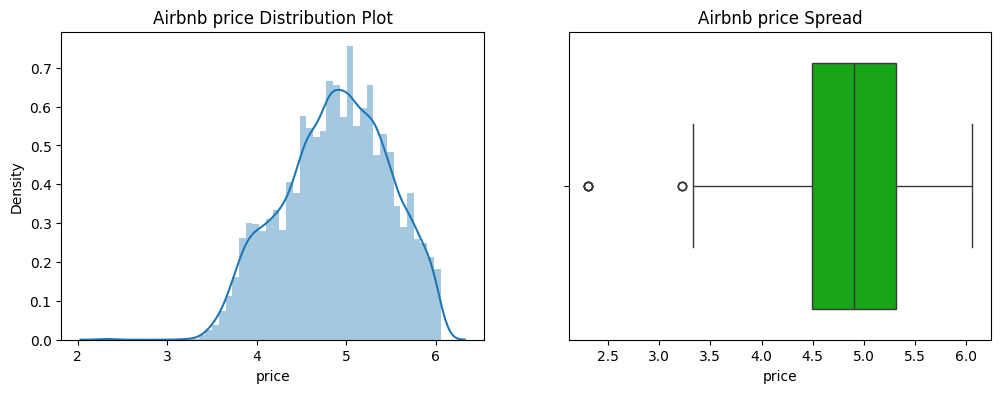

In [70]:
data = data_cleaned.copy()

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title('Airbnb price Distribution Plot')
sns.distplot(data.price)

plt.subplot(1,2,2)
plt.title('Airbnb price Spread')
sns.boxplot(x=data.price, palette='nipy_spectral')

plt.show()

In [71]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11712 entries, 0 to 11711
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   price                      11712 non-null  float64
 1   latitude                   11712 non-null  float64
 2   longitude                  11712 non-null  float64
 3   accommodates               11712 non-null  int64  
 4   bathrooms                  11712 non-null  float64
 5   bedrooms                   11712 non-null  float64
 6   beds                       11712 non-null  float64
 7   amenities                  11712 non-null  str    
 8   review_scores_value        11712 non-null  float64
 9   license                    11712 non-null  bool   
 10  instant_bookable           11712 non-null  bool   
 11  amenities_grouped          11712 non-null  str    
 12  amenity_kitchen            11712 non-null  bool   
 13  amenity_dryer              11712 non-null  bool   
 14  a

In [50]:
#Se establece las variables de entrada 'X' y la variable de salida 'y'

X = data.drop(columns = ["price","amenity_parking","amenity_dryer","amenity_tv","amenity_hair_dryer","amenity_cleaning_products","amenity_washer","amenity_luxurious"])
y = data['price']

In [72]:
#Se establece las variables de entrada 'X' y la variable de salida 'y'

X = data.drop(columns = ["price","amenities","amenities_grouped"])
y = data['price']

Obtenemos los datos de entrenamiento y prueba para los modelos iniciales

In [73]:
#En este caso, el 80% de los datos se utilizarán para entrenar el modelo.
X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y.values.reshape(-1,1),
                                        train_size   = 0.8,
                                        random_state = 1234,
                                        shuffle      = True
                                    )

#Escalar las variables de entrada
num_vars = X.select_dtypes(include=['number']).columns.tolist()
print("Columnas Numéricas:{}".format(num_vars))

scaler = StandardScaler()

X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars]  = scaler.transform(X_test[num_vars])

Columnas Numéricas:['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'review_scores_value', 'amenities_count', 'distance_min']


Obtenemos los datos completos para los tunnings de los modelos y el escalado en producción

In [74]:
# Nuevamente se asigna a 'X_Completo' y 'y_Completo' los datos entrada y salida respectivamente
X_Completo = X
y_Completo = y

# Se escalan los datos numéricos de entrada
X_Completo[num_vars] = scaler.fit_transform(X_Completo[num_vars])

# Se guarda el scaler
#joblib.dump(scaler, '../modelos/scaler/MinMaxFull_Airbnb_V1.pkl')

## 4. Validación de modelos

In [75]:
X.shape

(11712, 28)

In [9]:
# Diccionario para almacenar los resultados de los modelos
resultados_modelos = {}

### 4.1 MLP

In [76]:
model_mlp = Sequential([
    Dense(32, activation="relu", input_shape=(X.shape[1],)),
    Dropout(0.3),
    Dense(16, activation="relu"),
    Dense(1)
])

In [77]:
model_mlp.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [78]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

In [79]:
history_mlp = model_mlp.fit(
    X_train,
    y_train,
    validation_split=0.15,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/50
249/249 - 3s - 12ms/step - loss: 5.1144 - mae: 1.7283 - val_loss: 0.4930 - val_mae: 0.5478
Epoch 2/50
249/249 - 1s - 4ms/step - loss: 0.9900 - mae: 0.7873 - val_loss: 0.3109 - val_mae: 0.4265
Epoch 3/50
249/249 - 1s - 4ms/step - loss: 0.7371 - mae: 0.6804 - val_loss: 0.2830 - val_mae: 0.4090
Epoch 4/50
249/249 - 1s - 5ms/step - loss: 0.5821 - mae: 0.6038 - val_loss: 0.2678 - val_mae: 0.3989
Epoch 5/50
249/249 - 1s - 5ms/step - loss: 0.4852 - mae: 0.5540 - val_loss: 0.3314 - val_mae: 0.4562
Epoch 6/50
249/249 - 1s - 5ms/step - loss: 0.4297 - mae: 0.5174 - val_loss: 0.2622 - val_mae: 0.3980
Epoch 7/50
249/249 - 1s - 4ms/step - loss: 0.3651 - mae: 0.4763 - val_loss: 0.2722 - val_mae: 0.4104
Epoch 8/50
249/249 - 1s - 5ms/step - loss: 0.3104 - mae: 0.4410 - val_loss: 0.3086 - val_mae: 0.4464
Epoch 9/50
249/249 - 1s - 5ms/step - loss: 0.2785 - mae: 0.4158 - val_loss: 0.2173 - val_mae: 0.3635
Epoch 10/50
249/249 - 1s - 5ms/step - loss: 0.2462 - mae: 0.3919 - val_loss: 0.2135 - val_

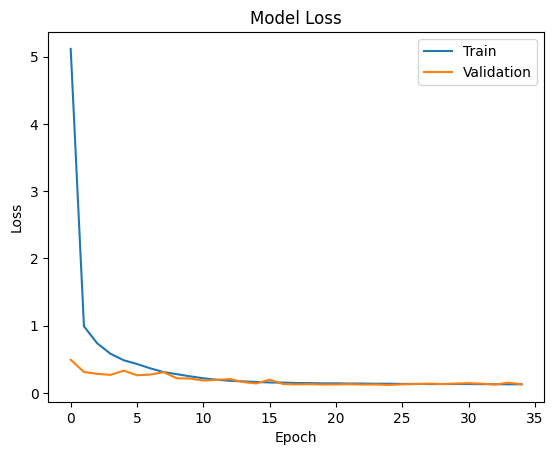

In [80]:
import matplotlib.pyplot as plt

plt.plot(history_mlp.history["loss"])
plt.plot(history_mlp.history["val_loss"])

plt.title("Model Loss")

plt.ylabel("Loss")

plt.xlabel("Epoch")

plt.legend(["Train", "Validation"])

plt.show()

In [81]:
test_loss, test_mae = model_mlp.evaluate(
    X_test,
    y_test
)

print("Test MAE:", test_mae)

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1304 - mae: 0.2816
Test MAE: 0.2816159427165985


In [82]:
y_pred_log = model_mlp.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_real = np.expm1(y_test)

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [83]:
from sklearn.metrics import r2_score
import numpy as np

r2 = r2_score(y_real, y_pred)

print("R²:", r2)

R²: 0.5363577912962015


### 4.1 Random Forest 

#### Creación de modelo inicial
Se crea para validar inicialmente si es viable la regresion o no, segun el valor de R^2. 

In [59]:
# Creación del modelo de Random Forest
modelRF = RandomForestRegressor(
            n_estimators = 10,
            criterion    = 'squared_error',
            max_depth    = None,
            max_features = 'sqrt',
            oob_score    = False,   #out-of-bag samples
            n_jobs       = -1,
            random_state = 123
         )

# Entrenamiento del modelo
modelRF.fit(X_train, y_train)

RandomForestRegressor(max_features='sqrt', n_estimators=10, n_jobs=-1,
                      random_state=123)

In [60]:
# Error de test del modelo inicial
predicciones = modelRF.predict(X = X_test)

rmse = np.sqrt(mean_squared_error(y_true  = y_test, y_pred  = predicciones))
print(f"El error (RMSE) de test es: {rmse}")

mae = mean_absolute_error(y_true  = y_test, y_pred  = predicciones)
print(f"El error (MAE) de test es: {mae}")

r2 = r2_score(y_test, predicciones)
print(f"El error (R2) de test es: {r2}")

El error (RMSE) de test es: 0.3311448700515794
El error (MAE) de test es: 0.2440800157026815
El error (R2) de test es: 0.6932990627979142


Como el valor de R2 es del 69.3% es viable tratar de ajustar los hiperparametros para obtener mejores predicciones

#### Tunning del modelo
Calculamos cuales son los hiperparametros ideales para evaluar el modelo. 

##### Cálculo del rango de cantidad de estimadores (árboles)

Valor óptimo de n_estimators(árboles): 97


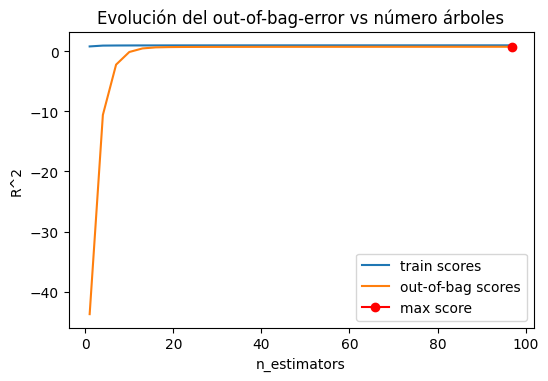

In [61]:
# Validación empleando el Out-of-Bag error:
train_scores = []
oob_scores   = []

# Valores evaluados
estimator_range = range(1, 100, 3)

# Bucle para entrenar un modelo con cada valor de n_estimators y extraer su error
# de entrenamiento y de Out-of-Bag.

for n_estimators in estimator_range:
    modelRF = RandomForestRegressor(
                n_estimators = n_estimators,
                criterion    = 'squared_error', # mean squared error
                max_depth    = None,
                max_features = 'sqrt',
                oob_score    = True,
                n_jobs       = -1,
                random_state = 123
             )
    modelRF.fit(X_Completo, y_Completo)
    train_scores.append(modelRF.score(X_Completo, y_Completo))
    oob_scores.append(modelRF.oob_score_)

# Gráfico con la evolución de los errores
fig, ax = plt.subplots(figsize=(6, 3.84))
ax.plot(estimator_range, train_scores, label="train scores")
ax.plot(estimator_range, oob_scores, label="out-of-bag scores")
ax.plot(estimator_range[np.argmax(oob_scores)], max(oob_scores),
        marker='o', color = "red", label="max score")
ax.set_ylabel("R^2")
ax.set_xlabel("n_estimators")
ax.set_title("Evolución del out-of-bag-error vs número árboles")
plt.legend();
print(f"Valor óptimo de n_estimators(árboles): {estimator_range[np.argmax(oob_scores)]}")

> El valor ideal de Estimadores segun la grafica seria de **20**

Valor óptimo de n_estimators: 97


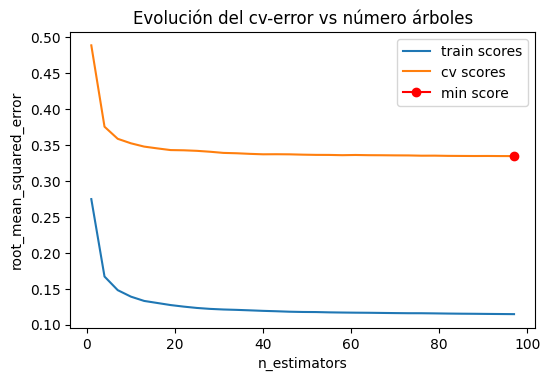

In [62]:
# Validación empleando k-cross-validation y neg_root_mean_squared_error
train_scores = []
cv_scores    = []

# Valores evaluados
estimator_range = range(1, 100, 3)

# Bucle para entrenar un modelo con cada valor de n_estimators y extraer su error
# de entrenamiento y de k-cross-validation.
for n_estimators in estimator_range:

    modelRF = RandomForestRegressor(
                n_estimators = n_estimators,
                criterion    = 'squared_error', #mean squared error: mse
                max_depth    = None,
                max_features = 'sqrt',
                oob_score    = False,
                n_jobs       = -1,
                random_state = 123
             )

    # Error de train
    modelRF.fit(X_Completo, y_Completo)
    predicciones = modelRF.predict(X = X_Completo)
    rmse = np.sqrt(mean_squared_error(
            y_true  = y_Completo,
            y_pred  = predicciones))
    train_scores.append(rmse)

    # Error de validación cruzada
    scores = cross_val_score(
                estimator = modelRF,
                X         = X_Completo,
                y         = y_Completo,
                scoring   = 'neg_root_mean_squared_error',
                cv        = 5
             )
    # Se agregan los scores de cross_val_score() y se pasa a positivo
    cv_scores.append(-1*scores.mean())

# Gráfico con la evolución de los errores
fig, ax = plt.subplots(figsize=(6, 3.84))
ax.plot(estimator_range, train_scores, label="train scores")
ax.plot(estimator_range, cv_scores, label="cv scores")
ax.plot(estimator_range[np.argmin(cv_scores)], min(cv_scores),
        marker='o', color = "red", label="min score")
ax.set_ylabel("root_mean_squared_error")
ax.set_xlabel("n_estimators")
ax.set_title("Evolución del cv-error vs número árboles")
plt.legend();
print(f"Valor óptimo de n_estimators: {estimator_range[np.argmin(cv_scores)]}")

> Comprobamos que con 20 Arboles es mas que suficiente para tener errores estables

##### Cálculo del rango de cantidad de características

Valor óptimo de max_features: 10


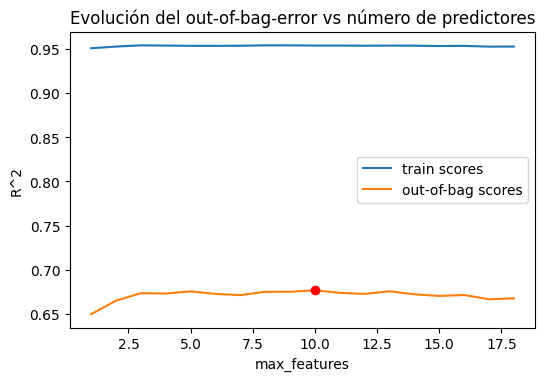

In [63]:
# Validación empleando el Out-of-Bag error
train_scores = []
oob_scores   = []

# Valores evaluados
max_features_range = range(1, X_Completo.shape[1] + 1, 1) #X_train.shape[1] = total de características

# Bucle para entrenar un modelo con cada valor de max_features y extraer su error
# de entrenamiento y de Out-of-Bag.
for max_features in max_features_range:
    modelRF = RandomForestRegressor(
                n_estimators = 20,
                criterion    = 'squared_error',
                max_depth    = None,
                max_features = max_features,
                oob_score    = True,
                n_jobs       = -1,
                random_state = 123
             )
    modelRF.fit(X_Completo, y_Completo)
    train_scores.append(modelRF.score(X_Completo, y_Completo))
    oob_scores.append(modelRF.oob_score_)

# Gráfico con la evolución de los errores
fig, ax = plt.subplots(figsize=(6, 3.84))
ax.plot(max_features_range, train_scores, label="train scores")
ax.plot(max_features_range, oob_scores, label="out-of-bag scores")
ax.plot(max_features_range[np.argmax(oob_scores)], max(oob_scores),
        marker='o', color = "red")
ax.set_ylabel("R^2")
ax.set_xlabel("max_features")
ax.set_title("Evolución del out-of-bag-error vs número de predictores")
plt.legend();
print(f"Valor óptimo de max_features: {max_features_range[np.argmax(oob_scores)]}")

> El valor máximo de las características idealmente según la grafica seria de **10**

Valor óptimo de max_features: 4


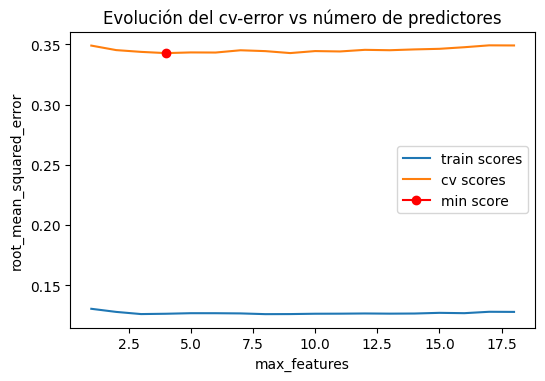

In [64]:
# Validación empleando k-cross-validation y neg_root_mean_squared_error
train_scores = []
cv_scores    = []

# Valores evaluados
max_features_range = range(1, X_Completo.shape[1] + 1, 1)

# Bucle para entrenar un modelo con cada valor de max_features y extraer su error
# de entrenamiento y de k-cross-validation.
for max_features in max_features_range:

    modelRF = RandomForestRegressor(
                n_estimators = 20,
                criterion    = 'squared_error',
                max_depth    = None,
                max_features = max_features,
                oob_score    = True,
                n_jobs       = -1,
                random_state = 123
             )

    # Error de train
    modelRF.fit(X_Completo, y_Completo)
    predicciones = modelRF.predict(X = X_Completo)
    rmse = np.sqrt(mean_squared_error(
            y_true  = y_Completo,
            y_pred  = predicciones))
    train_scores.append(rmse)

    # Error de validación cruzada
    scores = cross_val_score(
                estimator = modelRF,
                X         = X_Completo,
                y         = y_Completo,
                scoring   = 'neg_root_mean_squared_error',
                cv        = 5
             )
    # Se agregan los scores de cross_val_score() y se pasa a positivo
    cv_scores.append(-1*scores.mean())

# Gráfico con la evolución de los errores
fig, ax = plt.subplots(figsize=(6, 3.84))
ax.plot(max_features_range, train_scores, label="train scores")
ax.plot(max_features_range, cv_scores, label="cv scores")
ax.plot(max_features_range[np.argmin(cv_scores)], min(cv_scores),
        marker='o', color = "red", label="min score")
ax.set_ylabel("root_mean_squared_error")
ax.set_xlabel("max_features")
ax.set_title("Evolución del cv-error vs número de predictores")
plt.legend();
print(f"Valor óptimo de max_features: {max_features_range[np.argmin(cv_scores)]}")

> Los analisis anteriores determinan que el numero de caracteristicas optimo estaria entre **4** y **10**

##### Validación cruzada con múltiples hiperparámetros

In [98]:
#Se entrena el modelo con múltiples hiperparámetros buscando el mejor

# Definir el modelo AdaBoostRegressor
modelRF = RandomForestRegressor(random_state = 123)

CV = 10

parameters =  {
                'n_estimators': [15, 20, 25],
                'max_features': [4, 6, 8, 10],
                'max_depth'   : [10, 20, 30]
                }

grid_RF = GridSearchCV(
                    estimator  = modelRF,
                    param_grid = parameters,
                    #scoring    = 'neg_root_mean_squared_error',
                    n_jobs     = - 1,
                    cv         = CV,
                    refit      = True,
                    verbose    = 3,
                    return_train_score = True
                   )

grid_RF.fit(X = X_Completo, y = y_Completo)

Fitting 10 folds for each of 36 candidates, totalling 360 fits
[CV 1/10] END max_depth=10, max_features=4, n_estimators=15;, score=(train=0.774, test=0.613) total time=   0.3s
[CV 3/10] END max_depth=10, max_features=4, n_estimators=15;, score=(train=0.773, test=0.699) total time=   0.3s
[CV 4/10] END max_depth=10, max_features=4, n_estimators=15;, score=(train=0.771, test=0.680) total time=   0.3s
[CV 5/10] END max_depth=10, max_features=4, n_estimators=15;, score=(train=0.776, test=0.599) total time=   0.3s
[CV 8/10] END max_depth=10, max_features=4, n_estimators=15;, score=(train=0.769, test=0.680) total time=   0.3s
[CV 7/10] END max_depth=10, max_features=4, n_estimators=15;, score=(train=0.773, test=0.673) total time=   0.3s
[CV 2/10] END max_depth=10, max_features=4, n_estimators=15;, score=(train=0.777, test=0.581) total time=   0.4s
[CV 10/10] END max_depth=10, max_features=4, n_estimators=15;, score=(train=0.762, test=0.756) total time=   0.3s
[CV 6/10] END max_depth=10, max_

GridSearchCV(cv=10, estimator=RandomForestRegressor(random_state=123),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30],
                         'max_features': [4, 6, 8, 10],
                         'n_estimators': [15, 20, 25]},
             return_train_score=True, verbose=3)

In [99]:
# Resultados
resultados = pd.DataFrame(grid_RF.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)') \
    .drop(columns = 'params') \
    .sort_values('mean_test_score', ascending = False) \
    .head(4)

,param_max_depth,param_max_features,param_n_estimators,mean_test_score,std_test_score,mean_train_score,std_train_score
29,30,6,25,0.679504,0.057796,0.956110,0.001250
17,20,6,25,0.677569,0.060752,0.949850,0.001606
20,20,8,25,0.676812,0.060717,0.950621,0.001636
26,30,4,25,0.676441,0.057842,0.956028,0.001183


In [100]:
# Obtener los resultados del grid search
results_grid_RF = pd.DataFrame(grid_RF.cv_results_)

# Seleccionar las columnas deseadas
columns_grid_RF = ['param_max_depth']  + \
                    ['param_max_features']  + \
                    ['param_n_estimators']  + \
                    ['mean_test_score', 'std_test_score']  + \
                    [f'split{i}_test_score' for i in range(CV)]

# Filtrar y mostrar los resultados
results_grid_RF_filtered = results_grid_RF[columns_grid_RF]

# Crear la columna scoreWithStd: R² / std
results_grid_RF_filtered['scoreWithStd'] = results_grid_RF_filtered.apply(
    lambda row: row['mean_test_score'] / row['std_test_score'] if row['std_test_score'] != 0 else 0,
    axis=1
)

# Encuentra el índice del mínimo valor en la columna scoreWithStd
indice_max_scoreWithStd = results_grid_RF_filtered['scoreWithStd'].idxmax()

# Mostrar los scores promedios por cada parámetro
results_grid_RF_filtered[['param_max_depth', 'param_max_features','param_n_estimators', 'mean_test_score', 'std_test_score', 'scoreWithStd']]


,param_max_depth,param_max_features,param_n_estimators,mean_test_score,std_test_score,scoreWithStd
0,10,4,15,0.665081,0.057616,11.543274
1,10,4,20,0.666243,0.057526,11.581514
2,10,4,25,0.668026,0.058516,11.416080
3,10,6,15,0.671437,0.058302,11.516627
4,10,6,20,0.672928,0.057922,11.617902
5,10,6,25,0.673686,0.057927,11.629963
6,10,8,15,0.670760,0.058405,11.484670
7,10,8,20,0.672223,0.058147,11.560760
8,10,8,25,0.673836,0.058009,11.616043
9,10,10,15,0.668005,0.061267,10.903147


In [101]:
# Top 3 de los mejores scores
results_grid_RF_filtered.sort_values(by='scoreWithStd', ascending=False).head(3)[
    ['param_max_depth', 'param_max_features','param_n_estimators', 'mean_test_score', 'std_test_score', 'scoreWithStd']]

,param_max_depth,param_max_features,param_n_estimators,mean_test_score,std_test_score,scoreWithStd
13,20,4,20,0.671647,0.053894,12.462371
12,20,4,15,0.664908,0.054041,12.303865
14,20,4,25,0.675378,0.055296,12.213951


#### Seleccionamos el mejor modelo
Tomando en cuenta que los valores de mean_test_score para el mejor estimador y el del mejor scoreWithStd son similares, con muy pocos cambios en su desviación estandar optamos por elegir los mejores parámetros que considera mejor el GridSearchCV

In [102]:
# Se identifican los mejores hiperparámetros
best_params = grid_RF.best_params_
print('Best Parameters : ',best_params)

Best Parameters :  {'max_depth': 30, 'max_features': 6, 'n_estimators': 25}


In [103]:
modelRF = grid_RF.best_estimator_
modelRF.fit(X_Completo, y_Completo)

RandomForestRegressor(max_depth=30, max_features=6, n_estimators=25,
                      random_state=123)

In [104]:
# Guardar modelo
joblib.dump(modelRF, '../modelos/regresion/randomForest_AirbnbNY_V1.pkl')

['../modelos/regresion/randomForest_AirbnbNY_V1.pkl']

Agregamos el resultado de R² para Random Forest

In [105]:
resultados_modelos['Random Forest Regressor'] = results_grid_RF['mean_test_score'].max()

##### Importancia de las características

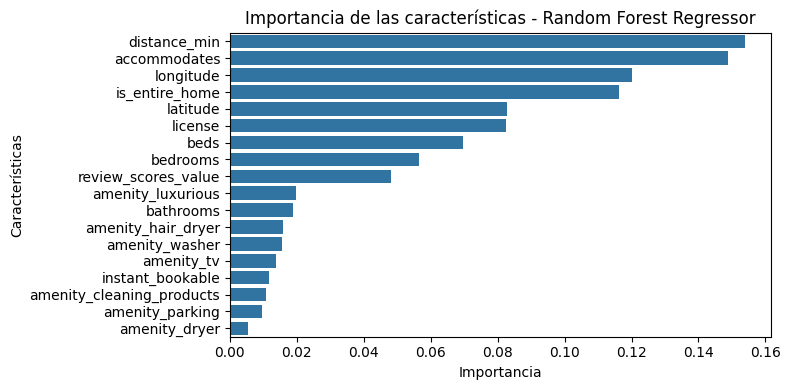

In [106]:
importancia_predictores = pd.DataFrame(
                            {'Predictor': X.columns,
                             'Importancia': modelRF.feature_importances_}
                            )

plt.figure(figsize=(8, 4))
sns.barplot(x='Importancia', 
            y='Predictor', 
            data=importancia_predictores, 
            order=importancia_predictores.sort_values('Importancia', ascending=False)['Predictor']
            )
plt.title('Importancia de las características - Random Forest Regressor')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.tight_layout()
plt.show()

### 4.2 Arból de Decision 

Para definir las columnas mas relevantes 

#### Creación de modelo inicial
Se crea para validar inicialmente si es viable la regresion o no, segun el valor de R^2. 

In [74]:
# Creación del modelo
dTreeR = DecisionTreeRegressor(
            max_depth         = 10,
            random_state      = 123
          )

# Entrenamiento del modelo
dTreeR.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, random_state=123)

In [75]:
print('Training:', dTreeR.score(X_train,y_train))
print('Test    :',r2_score(y_test,dTreeR.predict(X_test)))

Training: 0.7792279011712347
Test    : 0.6083177718361172


Como el valor de R2 es del 60.8% es viable tratar de ajustar los hiperparametros para obtener mejores predicciones

#### Tunning del modelo

##### Validación cruzada con múltiples hiperparámetros
Se entrena el modelo con múltiples hiperparámetros buscando el mejor.

In [76]:
# Calcular los hiperparámetros óptimos mediante GridSearchCV

#Se crea una instancia de una DecisionTreeRegressor
modelTreeR = DecisionTreeRegressor()

CV = 10

#Se establecen los hiperparámetros
parameters = {'max_depth': [2, 4, 6, 8, 10, 20, 50],
              'min_samples_split': [15, 30, 45, 60],
              'min_samples_leaf' : [15, 30, 45, 60],
              'max_features' : ['auto', 'sqrt', 'log2']
             }

# Se define un GridSearchCV con una validacion cruzada de 10 pliegues y con todos los
# hiperparametros establecidos anteriormente
grid_TreeR = GridSearchCV(
                          modelTreeR,
                          param_grid=parameters,
                          cv=CV,
                          verbose=3)

#Se entrena el GridSearchCV anterior con los datos completos
grid_TreeR.fit(X_Completo,y_Completo)

Fitting 10 folds for each of 336 candidates, totalling 3360 fits
[CV 1/10] END max_depth=2, max_features=auto, min_samples_leaf=15, min_samples_split=15;, score=nan total time=   0.0s
[CV 2/10] END max_depth=2, max_features=auto, min_samples_leaf=15, min_samples_split=15;, score=nan total time=   0.0s
[CV 3/10] END max_depth=2, max_features=auto, min_samples_leaf=15, min_samples_split=15;, score=nan total time=   0.0s
[CV 4/10] END max_depth=2, max_features=auto, min_samples_leaf=15, min_samples_split=15;, score=nan total time=   0.0s
[CV 5/10] END max_depth=2, max_features=auto, min_samples_leaf=15, min_samples_split=15;, score=nan total time=   0.0s
[CV 6/10] END max_depth=2, max_features=auto, min_samples_leaf=15, min_samples_split=15;, score=nan total time=   0.0s
[CV 7/10] END max_depth=2, max_features=auto, min_samples_leaf=15, min_samples_split=15;, score=nan total time=   0.0s
[CV 8/10] END max_depth=2, max_features=auto, min_samples_leaf=15, min_samples_split=15;, score=nan to

GridSearchCV(cv=10, estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': [2, 4, 6, 8, 10, 20, 50],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [15, 30, 45, 60],
                         'min_samples_split': [15, 30, 45, 60]},
             verbose=3)

In [77]:
# Resultados
# ==============================================================================
resultados = pd.DataFrame(grid_TreeR.cv_results_)
resultados.filter(regex = '(param*|mean_t|std_t)') \
    .drop(columns = 'params') \
    .sort_values('mean_test_score', ascending = False) \
    .head(4)


,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,mean_test_score,std_test_score
306,50,sqrt,15,45,0.595465,0.049916
258,20,sqrt,15,45,0.587880,0.055096
304,50,sqrt,15,15,0.587666,0.056794
211,10,sqrt,15,60,0.586982,0.064188


In [78]:
# Se identifican los mejores hiperparámetros
best_params = grid_TreeR.best_params_
print('Best Parameters : ',best_params)

Best Parameters :  {'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 15, 'min_samples_split': 45}


##### Modificando CCP Alpha
Se entrena el modelo con múltiples valores de CCP Alpha que es el parámetro encargado de "podar" el árbol

In [79]:
#Se crea una instancia de una DecisionTreeRegressor
modelTreeR_ccp = DecisionTreeRegressor( random_state = 123)

# Definir los parámetros para la búsqueda en la cuadrícula
parameters = {'ccp_alpha': np.logspace(-6, 3, 9)} # Valores entre 0.000001 y 100 en una escala logarítmica

# definicion de la variable con el número de pliegues
CV = 10

# Se define un GridSearchCV con una validacion cruzada de 10 pliegues y con todos los
#hierparametros establecidos anteriormente
grid_TreeR = GridSearchCV(
                          modelTreeR_ccp,
                          param_grid=parameters,
                          cv=CV,
                          verbose=3)

#Se entrena el GridSearchCV anterior (2 min. aprox.) con los datos completos
grid_TreeR.fit(X_Completo,y_Completo)

Fitting 10 folds for each of 9 candidates, totalling 90 fits
[CV 1/10] END ..................ccp_alpha=1e-06;, score=0.234 total time=   0.5s
[CV 2/10] END ..................ccp_alpha=1e-06;, score=0.266 total time=   0.4s
[CV 3/10] END ..................ccp_alpha=1e-06;, score=0.456 total time=   0.4s
[CV 4/10] END ..................ccp_alpha=1e-06;, score=0.355 total time=   0.4s
[CV 5/10] END ..................ccp_alpha=1e-06;, score=0.310 total time=   0.4s
[CV 6/10] END ..................ccp_alpha=1e-06;, score=0.323 total time=   0.4s
[CV 7/10] END ..................ccp_alpha=1e-06;, score=0.435 total time=   0.4s
[CV 8/10] END ..................ccp_alpha=1e-06;, score=0.385 total time=   0.4s
[CV 9/10] END ..................ccp_alpha=1e-06;, score=0.504 total time=   0.4s
[CV 10/10] END .................ccp_alpha=1e-06;, score=0.451 total time=   0.4s
[CV 1/10] END ..ccp_alpha=1.333521432163324e-05;, score=0.295 total time=   0.6s
[CV 2/10] END ..ccp_alpha=1.333521432163324e-05;

GridSearchCV(cv=10, estimator=DecisionTreeRegressor(random_state=123),
             param_grid={'ccp_alpha': array([1.00000000e-06, 1.33352143e-05, 1.77827941e-04, 2.37137371e-03,
       3.16227766e-02, 4.21696503e-01, 5.62341325e+00, 7.49894209e+01,
       1.00000000e+03])},
             verbose=3)

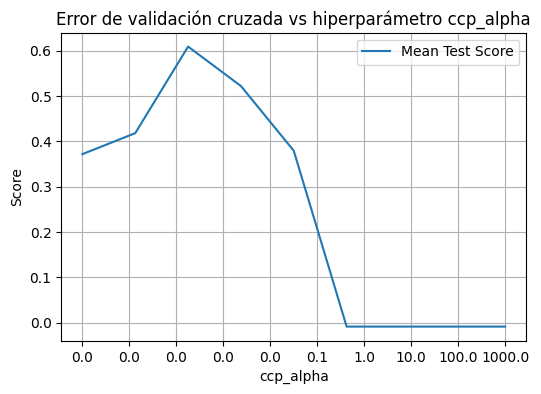

,param_ccp_alpha,mean_test_score,std_test_score
2,0.000178,0.609164,0.059553
3,0.002371,0.522080,0.044634
1,0.000013,0.418175,0.079795
4,0.031623,0.379266,0.045212
0,0.000001,0.371874,0.084648
5,0.421697,-0.008620,0.011681
6,5.623413,-0.008620,0.011681
7,74.989421,-0.008620,0.011681
8,1000.000000,-0.008620,0.011681


In [80]:
# Crear un DataFrame con los resultados del GridSearchCV
scores = pd.DataFrame(grid_TreeR.cv_results_)

# Construir la gráfica que muestra F1 de cada posible valor promedio de ccp_alpha y mean_train_score
fig, ax = plt.subplots(figsize=(6, 4))  # Aumentar el tamaño de la figura

# Variación de ccp_alpha
ax.set_xscale('log')
scores.plot(x='param_ccp_alpha', y='mean_test_score', ax=ax, label='Mean Test Score')
ax.set_title("Error de validación cruzada vs hiperparámetro ccp_alpha")
ax.set_xlabel("ccp_alpha")
ax.set_ylabel("Score")
ax.grid(True)

# Ajustar las etiquetas del eje X
ax.set_xticks(scores['param_ccp_alpha'])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_xaxis().set_minor_formatter(plt.NullFormatter())  # Ocultar etiquetas menores

# Asegurarse de que todas las etiquetas se muestren
ax.set_xticks(np.logspace(np.log10(scores['param_ccp_alpha'].min()), np.log10(scores['param_ccp_alpha'].max()), num=10))

plt.legend()
plt.show()

# Resultados
# ==============================================================================
resultados = pd.DataFrame(grid_TreeR.cv_results_)
resultados.filter(regex = '(param*|mean_t|std_t)') \
    .drop(columns = 'params') \
    .sort_values('mean_test_score', ascending = False) \
    .head(10)


#### Seleccionamos los mejores modelos

In [81]:
# Usar los mejores parámetros para crear el modelo
modelTreeR.set_params(**best_params)

modelTreeR.fit(X_Completo, y_Completo)

# Estructura del árbol final
print(f"Profundidad del árbol: {modelTreeR.get_depth()}")
print(f"Número de nodos terminales: {modelTreeR.get_n_leaves()}")
print(f"Score: {modelTreeR.score(X_Completo, y_Completo)}")

Profundidad del árbol: 16
Número de nodos terminales: 397
Score: 0.6591565185050218


In [82]:
# Creación del modelo com CCP_ALPHA
# ------------------------------------------------------------------------------
modelTreeR_ccp = DecisionTreeRegressor(
            ccp_alpha         = grid_TreeR.best_params_["ccp_alpha"],
            random_state      = 123
          )

# Entrenamiento del modelo
# ------------------------------------------------------------------------------
modelTreeR_ccp.fit(X_Completo, y_Completo)

# Estructura del árbol final
# ------------------------------------------------------------------------------
print(f"Profundidad del árbol: {modelTreeR_ccp.get_depth()}")
print(f"Número de nodos terminales: {modelTreeR_ccp.get_n_leaves()}")
print(f"Score: {modelTreeR_ccp.score(X_Completo, y_Completo)}")

Profundidad del árbol: 11
Número de nodos terminales: 97
Score: 0.6897139884762675


In [83]:
# Guardar los modelos entrenados
joblib.dump(modelTreeR, '../modelos/regresion/decisionTree_AirbnbNY_V1.pkl')
joblib.dump(modelTreeR_ccp, '../modelos/regresion/decisionTree_Ccp_AirbnbNY_V1.pkl')

['../modelos/regresion/decisionTree_Ccp_AirbnbNY_V1.pkl']

In [84]:
# Guardamos los resultados de R2 para ambos modelos
resultados_modelos['Decision Tree Regressor'] = modelTreeR.score(X_Completo, y_Completo)
resultados_modelos['Decision Tree CCP Regressor'] = modelTreeR_ccp.score(X_Completo, y_Completo)

##### Importancia de las características

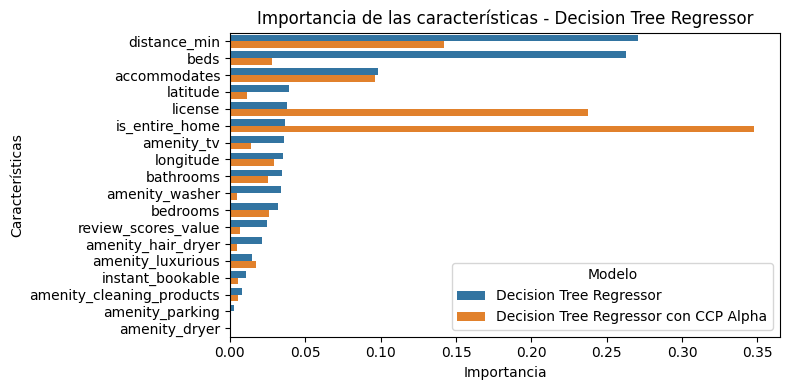

In [85]:
importancia_predictores = pd.DataFrame(
                            {'Modelo': 'Decision Tree Regressor',
                             'Predictor': X.columns,
                             'Importancia': modelTreeR.feature_importances_}
                            )

importancia_predictores_ccp = pd.DataFrame(
                            {'Modelo': 'Decision Tree Regressor con CCP Alpha',
                             'Predictor': X.columns,
                             'Importancia': modelTreeR_ccp.feature_importances_}
                            )

importancia_concatenada = pd.concat([importancia_predictores, importancia_predictores_ccp])

plt.figure(figsize=(8, 4))
sns.barplot(x='Importancia', 
            y='Predictor', 
            hue='Modelo',
            data=importancia_concatenada, 
            order=importancia_predictores.sort_values('Importancia', ascending=False)['Predictor']
            )
plt.title('Importancia de las características - Decision Tree Regressor')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.tight_layout()
plt.show()

### 4.3 AdaBoost para Regresion

#### Creación de modelo inicial
Se crea para validar inicialmente si es viable la regresion o no, segun el valor de R^2. 

In [111]:
modelAdaBoost = AdaBoostRegressor(n_estimators=100, random_state=1)
modelAdaBoost.fit(X_train, y_train)

AdaBoostRegressor(n_estimators=100, random_state=1)

In [112]:
# Error de test del modelo inicial
predicciones = modelAdaBoost.predict(X = X_test)

rmse = np.sqrt(mean_squared_error(y_true  = y_test, y_pred  = predicciones))
print(f"El error (RMSE) de test es: {rmse}")

mae = mean_absolute_error(y_true  = y_test, y_pred  = predicciones)
print(f"El error (MAE) de test es: {mae}")

r2 = r2_score(y_test, predicciones)
print(f"El error (R2) de test es: {r2}")

El error (RMSE) de test es: 0.42007398266808843
El error (MAE) de test es: 0.33687164621551635
El error (R2) de test es: 0.5064506223822566


EL R² inicial es muy bajo, por lo que se optará por descartar el tunning del modelo AdaBoost.

In [113]:
resultados_modelos['AdaBoost Regressor'] = r2

### 4.4 Gradient Boosting para Regresion

#### Creación de modelo inicial
Se crea para validar inicialmente si es viable la regresion o no, segun el valor de R^2. 

In [88]:
modelGradientBoosting = GradientBoostingRegressor(n_estimators=100, random_state=1)
modelGradientBoosting.fit(X_train, y_train)

GradientBoostingRegressor(random_state=1)

In [89]:
# Error de test del modelo inicial
predicciones = modelGradientBoosting.predict(X = X_test)

rmse = np.sqrt(mean_squared_error(y_true  = y_test, y_pred  = predicciones))
print(f"El error (RMSE) de test es: {rmse}")

mae = mean_absolute_error(y_true  = y_test, y_pred  = predicciones)
print(f"El error (MAE) de test es: {mae}")

r2 = r2_score(y_true  = y_test, y_pred  = predicciones)
print(f"El error (R2) de test es: {r2}")

El error (RMSE) de test es: 0.3342377635755408
El error (MAE) de test es: 0.2567354032701
El error (R2) de test es: 0.687543133232386


Como el valor de R2 es del 68.7% es viable tratar de ajustar los hiperparametros para obtener mejores predicciones

#### Tunning del modelo
Calculamos cuales son los hiperparametros ideales para evaluar el modelo. 

In [90]:
# Definir el modelo GradientBoosting
modelGrdB = GradientBoostingRegressor()

CV = 10

# Definir los parámetros a ajustar y sus posibles valores
parameters = {
    'n_estimators': range(1, 100, 5),
    'learning_rate': [0.1, 0.01, 0.001],
    'max_depth': [3, 5, 7]
}

grid_GrdB = GridSearchCV(
        estimator  = modelGrdB,
        param_grid = parameters,
        n_jobs     = - 1,
        cv         = CV, 
        refit      = True,
        verbose    = 0,
        return_train_score = True
       )

grid_GrdB.fit(X = X_Completo, y = y_Completo)

GridSearchCV(cv=10, estimator=GradientBoostingRegressor(), n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.01, 0.001],
                         'max_depth': [3, 5, 7],
                         'n_estimators': range(1, 100, 5)},
             return_train_score=True)

In [91]:
# Resultados
resultados = pd.DataFrame(grid_GrdB.cv_results_)
resultados.filter(regex = '(param*|mean_t|std_t)') \
    .drop(columns = 'params') \
    .sort_values('mean_test_score', ascending = False) \
    .head(4)

,param_learning_rate,param_max_depth,param_n_estimators,mean_test_score,std_test_score,mean_train_score,std_train_score
59,0.1,7,96,0.680807,0.057023,0.850485,0.004502
56,0.1,7,81,0.680458,0.057561,0.840894,0.004534
58,0.1,7,91,0.680457,0.057876,0.847518,0.004119
57,0.1,7,86,0.680399,0.057219,0.844217,0.004324


In [92]:
# Obtener los resultados del grid search
results_grid_GrdB = pd.DataFrame(grid_GrdB.cv_results_)

# Seleccionar las columnas deseadas
columns_grid_GrdB = ['param_learning_rate']  + \
                    ['param_max_depth']  + \
                    ['param_n_estimators']  + \
                    ['mean_test_score', 'std_test_score']  + \
                    [f'split{i}_test_score' for i in range(CV)]

# Filtrar y mostrar los resultados
results_grid_GrdB_filtered = results_grid_GrdB[columns_grid_GrdB]

# Crear la columna scoreWithStd: f1 / std
results_grid_GrdB_filtered['scoreWithStd'] = results_grid_GrdB_filtered.apply(
    lambda row: row['mean_test_score'] / row['std_test_score'] if row['std_test_score'] != 0 else 0,
    axis=1
)

# Encuentra el índice del máximo valor en la columna scoreWithStd
indice_max_scoreWithStd = results_grid_GrdB_filtered['scoreWithStd'].idxmax()

# Mostrar los scores promedios por cada parámetro
results_grid_GrdB_filtered[['param_learning_rate', 'param_max_depth', 'param_n_estimators','mean_test_score', 'std_test_score', 'scoreWithStd']]


,param_learning_rate,param_max_depth,param_n_estimators,mean_test_score,std_test_score,scoreWithStd
0,0.100,3,1,0.086504,0.011894,7.272929
1,0.100,3,6,0.365366,0.018847,19.385609
2,0.100,3,11,0.493841,0.021898,22.552124
3,0.100,3,16,0.556320,0.029063,19.142060
4,0.100,3,21,0.591804,0.034904,16.955234
...,...,...,...,...,...,...
175,0.001,7,76,0.082314,0.013052,6.306494
176,0.001,7,81,0.087839,0.013211,6.648899
177,0.001,7,86,0.093315,0.013365,6.981976
178,0.001,7,91,0.098744,0.013529,7.298455


In [93]:
# Top 3 de los mejores scores
results_grid_GrdB_filtered.sort_values(by='scoreWithStd', ascending=False).head(3)[
    ['param_learning_rate', 'param_max_depth' ,'param_n_estimators','mean_test_score', 'std_test_score', 'scoreWithStd']]

,param_learning_rate,param_max_depth,param_n_estimators,mean_test_score,std_test_score,scoreWithStd
2,0.10,3,11,0.493841,0.021898,22.552124
79,0.01,3,96,0.458935,0.020983,21.872006
78,0.01,3,91,0.447634,0.020540,21.793584


#### Seleccionamos el mejor modelo
Tomando en cuenta que los valores de mean_test_score para el mejor estimador y el del mejor scoreWithStd tienen una diferencia de casi 0.20, optamos por elegir los mejores parámetros que considera mejor el GridSearchCV

In [94]:
# Se identifican los mejores hiperparámetros
best_params = grid_GrdB.best_params_
print('Best Parameters : ',best_params)

Best Parameters :  {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 96}


In [95]:
# Se crea un modelo árbol de decisión con los mejores hiperparámetros 
modelGrdB = grid_GrdB.best_estimator_

#Se entrena el modelo con los datos completos
modelGrdB.fit(X_Completo, y_Completo)

GradientBoostingRegressor(max_depth=7, n_estimators=96)

In [96]:
joblib.dump(modelGrdB, '../modelos/regresion/gradientBoosting_AirbnbNY_V1.pkl')

['../modelos/regresion/gradientBoosting_AirbnbNY_V1.pkl']

In [97]:
resultados_modelos['Gradient Boosting Regressor'] = resultados['mean_test_score'].max()

### 4.5 Extreme Gradient Boosting para Regresion

#### Creación de modelo inicial
Se crea para validar inicialmente si es viable la regresion o no, segun el valor de R^2. 

In [21]:
modelXGBoosting = xgb.XGBRegressor(
    objective='reg:squarederror',  # Objetivo específico para modelos de regresión continua
    eval_metric='rmse',         # Métrica de evaluación durante el entrenamiento
    #use_label_encoder=False,
    random_state=42
)

modelXGBoosting.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [22]:
# Error de test del modelo inicial
predicciones = modelXGBoosting.predict(X = X_test)

rmse = np.sqrt(mean_squared_error(y_true  = y_test, y_pred  = predicciones))
print(f"El error (RMSE) de test es: {rmse}")

mae = mean_absolute_error(y_true  = y_test, y_pred  = predicciones)
print(f"El error (MAE) de test es: {mae}")

r2 = r2_score(y_true  = y_test, y_pred  = predicciones)
print(f"El error (R2) de test es: {r2}")

El error (RMSE) de test es: 0.3269753103291262
El error (MAE) de test es: 0.24250595087147195
El error (R2) de test es: 0.7009739932174691


Como el valor de R2 es del 70.04% es viable tratar de ajustar los hiperparametros para obtener mejores predicciones

#### Tunning del modelo
Calculamos cuales son los hiperparametros ideales para evaluar el modelo. 

In [23]:
param_grid_xgb = {
    'n_estimators': [125, 150, 175, 200, 225],      # Número de árboles
    'max_depth': [6, 8, 10, 12],             # Profundidad máxima del árbol
    'learning_rate': [0.01, 0.03, 0.05],    # Tasa de aprendizaj
    'subsample': [0.4, 0.5, 0.7]          # Submuestreo de filas
}

grid_search_xgb = GridSearchCV(
    estimator=modelXGBoosting, 
    param_grid=param_grid_xgb, 
    cv=10,                          # 5-fold cross-validation
    n_jobs=-1                      # Usar todos los núcleos disponibles
)

In [24]:
grid_search_xgb.fit(X = X_Completo, y = y_Completo)

GridSearchCV(cv=10,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False,
                                    eval_metric='rmse', feature_types=None,
                                    feature_weights=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=N...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.03, 0.05],
                         'max_depth': [6, 8, 10, 12],
                         'n_estimators': [125, 150, 175, 200, 225],
                         'subsample': [0.4, 0.5, 0.7]})

In [25]:
print(f"Mejores hiperparámetros: {grid_search_xgb.best_params_}")
print(f"Mejor R2: {grid_search_xgb.best_score_}")

Mejores hiperparámetros: {'learning_rate': 0.03, 'max_depth': 8, 'n_estimators': 225, 'subsample': 0.5}
Mejor R2: 0.6937745933294535


In [26]:
# Se crea un modelo XGBoost con los mejores hiperparámetros 
modelXGB = grid_search_xgb.best_estimator_

#Se entrena el modelo con los datos completos
modelXGB.fit(X = X_Completo, y = y_Completo)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=225,
             n_jobs=None, num_parallel_tree=None, ...)

In [28]:
joblib.dump(modelXGB, '../modelos/regresion/ExtremegradientBoosting_AirbnbNY_V1.pkl')

['../modelos/regresion/ExtremegradientBoosting_AirbnbNY_V1.pkl']

In [108]:
resultados_modelos['XGBoost Regressor'] = grid_search_xgb.best_score_

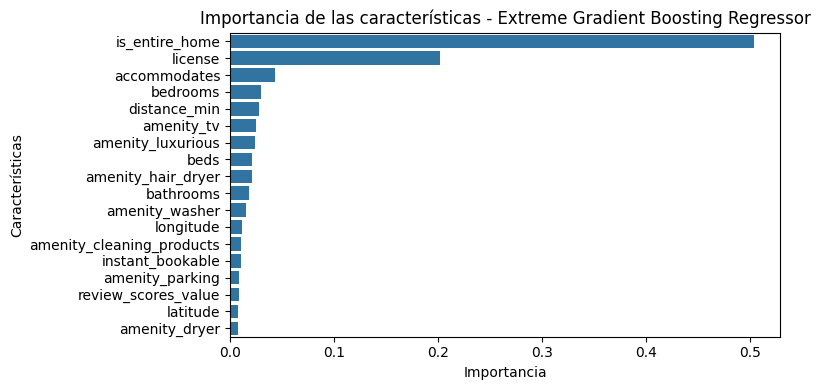

In [32]:
importancia_predictores = pd.DataFrame({
                             'Predictor': X.columns,
                             'Importancia': modelXGB.feature_importances_}
                            )

plt.figure(figsize=(8, 4))
sns.barplot(x='Importancia', 
            y='Predictor', 
            data=importancia_predictores, 
            order=importancia_predictores.sort_values('Importancia', ascending=False)['Predictor']
            )
plt.title('Importancia de las características - Extreme Gradient Boosting Regressor')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.tight_layout()
plt.show()

### 4.6 Creacion de Regresión Lineal Multiple

In [39]:
# Validar colinealidad
checkVIF(X_Completo)

,Features,VIF
1,longitude,61.82
6,review_scores_value,34.92
0,latitude,19.35
11,amenity_dryer,18.94
12,amenity_hair_dryer,13.28
3,bathrooms,12.21
16,distance_min,9.06
4,bedrooms,6.84
9,amenity_tv,6.24
2,accommodates,6.22


In [40]:
#Llamamos la funcion build_model definida al principio de este notebook que crea y entrena el modelo
modelo_X_train = build_model(X_Completo,y_Completo)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.586
Model:                            OLS   Adj. R-squared:                  0.585
Method:                 Least Squares   F-statistic:                     919.5
Date:                vie, 24 oct 2025   Prob (F-statistic):               0.00
Time:                        22:30:36   Log-Likelihood:                -5197.7
No. Observations:               11712   AIC:                         1.043e+04
Df Residuals:                   11693   BIC:                         1.057e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [41]:
#Se elimina la variable 'amenity_cleaning_products'
modelo_X_train = modelo_X_train.drop(["amenity_cleaning_products"], axis = 1)
# Colinealidad
checkVIF(modelo_X_train)

,Features,VIF
0,const,124.95
16,distance_min,4.11
2,longitude,3.48
12,amenity_dryer,3.10
3,accommodates,3.06
13,amenity_hair_dryer,3.06
6,beds,2.84
5,bedrooms,1.98
17,is_entire_home,1.59
1,latitude,1.54


In [42]:
#Llamamos la funcion build_model definida al principio de este notebook que crea y entrena el modelo

modelo_X_train = build_model(modelo_X_train,y_Completo)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.586
Model:                            OLS   Adj. R-squared:                  0.585
Method:                 Least Squares   F-statistic:                     973.3
Date:                vie, 24 oct 2025   Prob (F-statistic):               0.00
Time:                        22:30:50   Log-Likelihood:                -5198.9
No. Observations:               11712   AIC:                         1.043e+04
Df Residuals:                   11694   BIC:                         1.057e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   4.1451    

In [43]:
modelRegLineal = sm.OLS(y_Completo, modelo_X_train).fit()

In [44]:
print(f"Modelo Regresión Lineal Multiple - R2: {modelRegLineal.rsquared}")


Modelo Regresión Lineal Multiple - R2: 0.5859125394416587


Como el valor de R² es tan bajo no se va a tener en cuenta el modelo de regresión lineal múltiple

In [109]:
resultados_modelos['Regresion Lineal Multiple'] = modelRegLineal.rsquared

## 5. Evaluacion entre modelos de regresión

In [114]:
resultados_modelos

{'Random Forest Regressor': 0.6795038435468783,
 'Decision Tree Regressor': 0.6591565185050218,
 'Decision Tree CCP Regressor': 0.6897139884762675,
 'Gradient Boosting Regressor': 0.6808074580935407,
 'XGBoost Regressor': 0.6937745933294535,
 'Regresion Lineal Multiple': 0.5859125394416587,
 'AdaBoost Regressor': 0.5064506223822566}

## 6. Conclusiones

- La mejora de conjuntos de datos no sigue un método estandarizado, requiriendo enfoques personalizados según los objetivos.
- Mucho de este trabajo es de prueba y error, no hay fórmula mágica que aplique para todo de manera universal.
- El costo computacional de algunos modelos limita en gran manera una búsqueda de hiperparametros detallada.
- El feature engineering siempre se debe tener en cuenta durante la preparación de los datos, ya que según el objetivo de la predicción podemos crear nuevas características que aporten al modelo significativamente.